# Task-1: Circle Hough Transform. (12 marks)

In this task, you will use Hough transformation to detect circles in images. A circle centred at 
(𝑎, 𝑏) with radius 𝑟 can be parameterised by two equations.
𝑥 = 𝑎 + 𝑟 cos(𝜃) 𝑦 = 𝑏 + 𝑟 sin(𝜃) ∀𝜃
So, every point on a circle located at (𝑥, 𝑦) can be parameterised by equations as follows.
𝑎 = 𝑥 − 𝑟 cos(𝜃) 𝑏 = 𝑦 − 𝑟 sin(𝜃) ∀𝜃
Since 𝑟 is an unknown, it is also required to iterate possible radius values in a certain range.
𝑎 = 𝑥 − 𝑟 cos(𝜃) 𝑏 = 𝑦 − 𝑟 sin(𝜃) ∀𝜃∀𝑟
Each point from the image can generate infinitely many votes in the (𝑎, 𝑏, 𝑟) parameter space
theoretically. Points are represented as cones in the parameter space. If several points are from 
the same circle, their cones will intersect somewhere in the (𝑎, 𝑏, 𝑟) space. The coordinates of 
the intersection represent the centre and the radius of the circle. Thus, to detect a circle using 
the Hough transformation, we need to find out points in the (𝑎, 𝑏, 𝑟) space with a large number 
of votes.
Two images containing many circles are provided as follows.

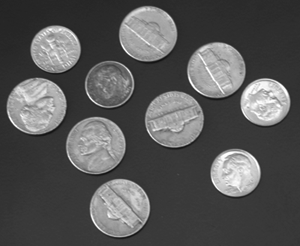

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

image1 = Image.open('images/coins.png')
image2  = Image.open('images/smarties.png')
display(image1)

1. Read the RGB images smarties.jpg and coins.jpg as NumPy arrays and convert RGB 
images to grayscale (0 mark).

In [2]:
import cv2
import numpy as np
# Read the png
coin_png = Image.open('images/coins.png')
coins = coin_png.convert('RGB')
smarties_png = Image.open('images/smarties.png')
smarties = smarties_png.convert('RGB')
# Convert the RGB images to grayscale
smarties_gray = cv2.cvtColor(np.array(smarties), cv2.COLOR_BGR2GRAY)
coins_gray = cv2.cvtColor(np.array(coins), cv2.COLOR_BGR2GRAY)

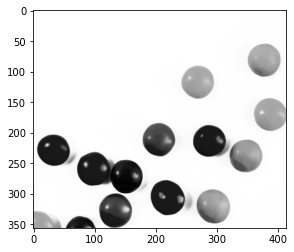

In [3]:
plt.imshow(smarties_gray, cmap='gray')
plt.show()

2. Apply the Canny edge detector on two grayscale images. You may need to try different sets 
of thresholds for the Canny detector and use the best-performing ones (1 mark).
Hint: You can use OpenCV library functions in this question.

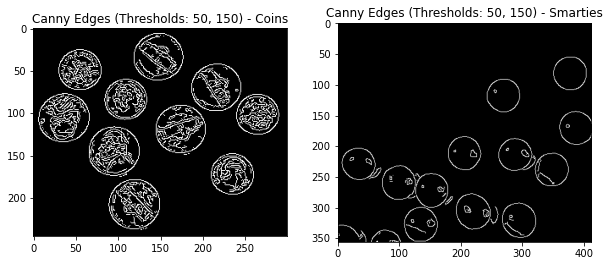

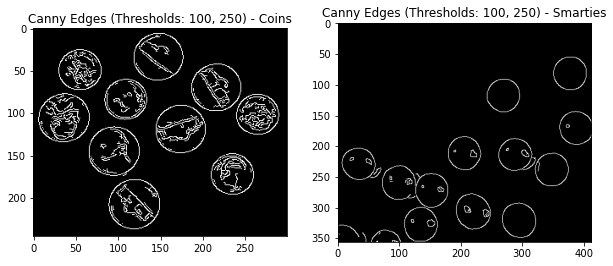

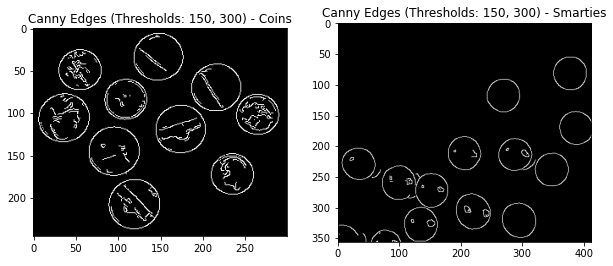

In [4]:
# Define the thresholds to be tested
thresholds = [(50, 150), (100, 250),(150,300)]

# Iterate over the threshold combinations
for i, (low_threshold, high_threshold) in enumerate(thresholds):
    # Apply Canny edge detection to the first image
    edges1 = cv2.Canny(coins_gray, low_threshold, high_threshold)
    # Apply Canny edge detection to the second image
    edges2 = cv2.Canny(smarties_gray, low_threshold, high_threshold)
    
    # Display the Canny edge detection results
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(edges1, cmap='gray')
    axs[0].set_title(f'Canny Edges (Thresholds: {low_threshold}, {high_threshold}) - Coins')
    axs[1].imshow(edges2, cmap='gray')
    axs[1].set_title(f'Canny Edges (Thresholds: {low_threshold}, {high_threshold}) - Smarties')
    plt.show()

(Text(0.5, 1.0, 'edges for smarties'), (-0.5, 412.5, 355.5, -0.5))

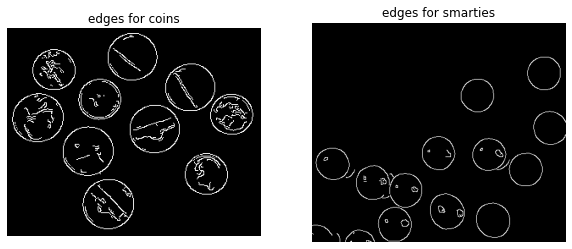

In [5]:
coins_edge = cv2.Canny(coins_gray, 150, 300)
smarties_edge = cv2.Canny(smarties_gray, 150, 300)
# Plot the results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(coins_edge, cmap='gray')
plt.title('edges for coins'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(smarties_edge, cmap='gray')
plt.title('edges for smarties'), plt.axis('off')

3. Develop a Hough Transformation function to identify circles within images, adhering to 
the methodology outlined above. Your hough_circle_transform function should 
return a list of circle candidates in the form of (𝑎, 𝑏, 𝑟) (3 marks).

• Use an accumulator to memorise the votes from each pixel.

• Iterate through each pixel in the edge-detected image, and for each edge pixel, 
increment the corresponding accumulator cells for all possible circle centres and radii.

• Set an appropriate threshold value for the accumulator to filter out potential false 
positives and identify the most likely circles. The threshold could be, for example, a 
ratio of the number of votes for a cell from the accumulator over the maximum possible 
votes for a single cell.

• The hough_circle_transform function might encompass input parameters such 
as input image, radius range, radius step, number of thetas and the accumulator 
threshold, for instance.a ratio of the number of votes for a cell from the accumulator over the maximum possible 
votes for a single cell.

• The hough_circle_transform function might encompass input parameters such 
as input image, radius range, radius step, number of thetas and the accumulator 
threshold, for instance.

In [6]:
#hough_circle_transform
#input image is canny image
def hough_circle_transform(edges, radius_range, radius_step, num_thetas, threshold):
    # Perform edge detection using the Canny algorithm
    # Get the height and width of the edge image
    height, width = edges.shape
    # Create an array of radius values within the specified range
    radius_range = np.arange(radius_range[0],radius_range[1],radius_step)
    # Initialize accumulator with zeros
    #a, b, r
    accumulator = np.zeros((height, width, len(radius_range)))
    # Find the indices of nonzero pixels in the edge image
    y_idxs, x_idxs = np.nonzero(edges)
    # Iterate through each nonzero pixel and increment the accumulator
    for r_idx, r in enumerate(radius_range):
        for theta_idx, theta in enumerate(np.linspace(0, 2 * np.pi, num_thetas)):
            # Calculate the center of the circle (a, b) using the pixel indices (x_idxs, y_idxs) and radius (r)
            a = np.round(x_idxs - r * np.cos(theta)).astype(int)
            b = np.round(y_idxs - r * np.sin(theta)).astype(int)
            # Filter out invalid indices
            valid_idxs = np.where((a >= 0) & (a < width) & (b >= 0) & (b < height))[0]
            a, b = a[valid_idxs], b[valid_idxs]
            # Increment the accumulator at the valid indices
            accumulator[b, a, r_idx] += 1
            
    # Find the maximum votes in the accumulator
    max_num = np.max(accumulator)
    # Identify circle candidates with votes above the threshold
    candidates = np.argwhere(accumulator / max_num > threshold)
    candidates = [(x, y, radius_range[r_idx]) for y, x, r_idx in candidates]
    return candidates

4. Circle candidates from the previous Hough transform function might include many 
neighbouring circles. Consequently, the implementation of a non-maximum suppression 
algorithm is essential to eliminate these duplicates. Implement non-maximum suppression 
and incorporate it into the outcomes obtained from the previous question (2 marks).
Hint: To perform non-maximum suppression, you can set up a pixel threshold and perform 
a pairwise comparison of all circle candidates, checking whether their absolute difference 
between 𝑎, 𝑏 or 𝑟 exceeds the designated threshold.

In [7]:
def non_max_suppression(circles, threshold):
    # Sort the circles by their votes (the third value in the tuple)
    circles = sorted(circles, key=lambda x: x[2], reverse=True)
    # Create a list to store the final circles after non-maximum suppression
    final_circles = []
    # Loop through each circle
    for i in range(len(circles)):
        # Check if the current circle overlaps with any of the final circles
        overlap = False
        for j in range(len(final_circles)):
            # Calculate the absolute differences between the circle parameters
            a_diff = abs(circles[i][0] - final_circles[j][0])
            b_diff = abs(circles[i][1] - final_circles[j][1])
            r_diff = abs(circles[i][2] - final_circles[j][2])
            # If the differences are below the threshold, consider the circles to overlap
            if a_diff <= threshold and b_diff <= threshold and r_diff <= threshold:
                overlap = True
                break
        # If the circle does not overlap with any of the final circles, add it to the final list
        if not overlap:
            final_circles.append(circles[i])
    return final_circles

5. Superimpose circles derived from the previous question on original images and display
images with circles (1 mark).
Hint: You may need to use the circle function from OpenCV.

In [8]:
# Define the range of radii to search for
radius_range = [10,30]
# Set the other parameters
radius_step = 1
num_thetas = 100
threshold = 0.5
# Run the Hough transform function
circles = hough_circle_transform(coins_edge, radius_range, radius_step, num_thetas, threshold)
print("achieve detect")

achieve detect


In [9]:
circles_smarties = hough_circle_transform(smarties_edge, radius_range, radius_step, num_thetas, threshold)
print("achieve detect")

achieve detect


(Text(0.5, 1.0, 'smarties circle detect'), (-0.5, 412.5, 355.5, -0.5))

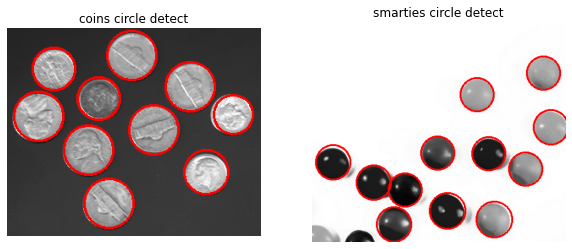

In [10]:
coins_bgr = cv2.cvtColor(coins_gray, cv2.COLOR_GRAY2BGR)
smarties_bgr = cv2.cvtColor(smarties_gray, cv2.COLOR_GRAY2BGR)
final_circles = non_max_suppression(circles, 50)
final_circles_smarties = non_max_suppression(circles_smarties, 50)
for x, y, r in final_circles:
    cv2.circle(coins_bgr, (x, y), r, (255, 0, 0), 2)
for x, y, r in final_circles_smarties:
    cv2.circle(smarties_bgr, (x, y), r, (255, 0, 0), 2)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(coins_bgr)
plt.title('coins circle detect'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(smarties_bgr)
plt.title('smarties circle detect'), plt.axis('off')

7. Examine the impact of different parameters of Circle Hough Transform (e.g., radius range, 
radius increment, theta count and a variety of thresholds) (1.5 marks).

In [ ]:
# Set the other parameters
#use coins
radius_step = 1
num_thetas = 100
threshold = 0.5
#change radius_range
radius_range_list = [[10,30],[30, 50],[50,80]]
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
# Iterate through the radius ranges and display the results in each subplot
for i, radius_range in enumerate(radius_range_list):
    print(f"Processing radius range {radius_range}...")
    circles = hough_circle_transform(coins_edge, radius_range, radius_step, num_thetas, threshold)
    final_circles = non_max_suppression(circles, 50)
    for x, y, r in final_circles:
        cv2.circle(coins_bgr, (x, y), r, (255, 0, 0), 2)
    # Display the result in a subplot
    axs[i].imshow(coins_bgr)
    axs[i].set_title(f"Radius Range: {radius_range}")
    # Reset the image to the original
    coins_bgr = cv2.cvtColor(coins_gray, cv2.COLOR_GRAY2BGR)
    
# Show the figure
plt.show()

In [ ]:
#change radius_range
#radius_step = 1
radius_range = [10,30]
num_thetas = 100
threshold = 0.5
radius_step_list = [1, 5, 10]
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, radius_step in enumerate(radius_step_list):
    print(f"Processing radius step {radius_step}...")
    circles = hough_circle_transform(coins_edge, radius_range, radius_step, num_thetas, threshold)
    final_circles = non_max_suppression(circles, 50)
    for x, y, r in final_circles:
        cv2.circle(coins_bgr, (x, y), r, (255, 0, 0), 2)
    # Display the result in a subplot
    axs[i].imshow(coins_bgr)
    axs[i].set_title(f"Radius step: {radius_step}")
    # Reset the image to the original
    coins_bgr = cv2.cvtColor(coins_gray, cv2.COLOR_GRAY2BGR)
    
# Show the figure
plt.show()

In [ ]:
#change num_thetas
#radius_step = 1
radius_range = [10,30]
radius_step = 1
num_thetas_list = [50,100,200]
threshold = 0.5
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, num_thetas in enumerate(num_thetas_list):
    print(f"Processing num_thetas {num_thetas}...")
    circles = hough_circle_transform(coins_edge, radius_range, radius_step, num_thetas, threshold)
    final_circles = non_max_suppression(circles, 50)
    for x, y, r in final_circles:
        cv2.circle(coins_bgr, (x, y), r, (255, 0, 0), 2)
    # Display the result in a subplot
    axs[i].imshow(coins_bgr)
    axs[i].set_title(f"Num_thetas: {num_thetas}")
    # Reset the image to the original
    coins_bgr = cv2.cvtColor(coins_gray, cv2.COLOR_GRAY2BGR)
# Show the figure
plt.show()

Processing threshold 0.3...
Processing threshold 0.5...
Processing threshold 0.7...


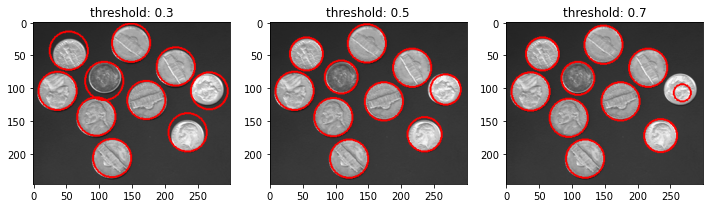

In [14]:
#change num_thetas
#radius_step = 1
radius_range = [10,30]
radius_step = 1
num_thetas=100
threshold_list = [0.3,0.5,0.7]
# Create a figure with 3 subplots
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for i, threshold in enumerate(threshold_list):
    print(f"Processing threshold {threshold}...")
    circles = hough_circle_transform(coins_edge, radius_range, radius_step, num_thetas, threshold)
    final_circles = non_max_suppression(circles, 50)
    for x, y, r in final_circles:
        cv2.circle(coins_bgr, (x, y), r, (255, 0, 0), 2)
    # Display the result in a subplot
    axs[i].imshow(coins_bgr)
    axs[i].set_title(f"threshold: {threshold}")
    # Reset the image to the original
    coins_bgr = cv2.cvtColor(coins_gray, cv2.COLOR_GRAY2BGR)
# Show the figure
plt.show()

8. An allocation of two marks will be awarded for time and memory efficiency (for both 
algorithmic asymptotic analysis and actual program runtime aspects) demonstrated by the 
functions in all questions (2 marks).

In [18]:
#hough
import time
radius_range = [10,30]
radius_step = 1
num_thetas = 100
threshold = 0.5
#update
start_time = time.time() # start time
circles = hough_circle_transform(coins_edge, radius_range, radius_step, num_thetas, threshold)

end_time = time.time() # end time
elapsed_time = end_time - start_time # runtime
print(f"Elapsed time of hough_circle_transform: {elapsed_time:.4f} seconds") # 输出函数运行时间

Elapsed time of hough_circle_transform: 0.7530 seconds


In [19]:
#non_max
coins_bgr = cv2.cvtColor(coins_gray, cv2.COLOR_GRAY2BGR)
start_time = time.time() # start time
final_circles = non_max_suppression(circles, 50)
end_time = time.time() # end time
elapsed_time = end_time - start_time # run time
print(f"Elapsed time of non_max_suppression: {elapsed_time:.4f} seconds")

Elapsed time of non_max_suppression: 0.0030 seconds
